# LangGraph Supervisor Demo

Acest notebook demonstrează implementarea unui sistem multi-agent folosind biblioteca `langgraph` și modelul Gemini 2.5 Flash de la Google. Sistemul este configurat pentru a rezolva o sarcină de cercetare și generare de raport, utilizând agenți specializați (cercetător, analist, scriitor, editor) și un supervizor care controlează fluxul execuției pe baza unor condiții. Scopul este de a ilustra cum se pot crea grafuri de agenți flexibile și inteligente pentru automatizarea sarcinilor complexe.

### Instalarea Bibliotecilor Necesare

Această celulă instalează bibliotecile `langgraph` și `langchain-google-genai`, esențiale pentru construirea și rularea grafului de agenți, precum și pentru interacțiunea cu modelele Gemini de la Google. Este o etapă pregătitoare obligatorie înainte de a rula codul principal.

In [ ]:
!pip install langgraph langchain-google-genai

### Definirea și Execuția Sistemului Multi-Agent (LangGraph)

Această celulă conține implementarea completă a sistemului multi-agent folosind `langgraph`. Sunt definite:

*   **`State`**: O structură de date care definește starea partajată a grafului pe parcursul execuției.
*   **`llm`**: Inițializarea modelului lingvistic mare (LLM) `gemini-2.5-flash` pentru a fi folosit de agenți.
*   **Funcțiile Agenților**: Fiecare funcție (`researcher`, `analyst`, `condition`, `write_one`, `write_more`, `editing_one`, `editing_more`) reprezintă un nod în graf și îndeplinește o sarcină specifică (cercetare, analiză, condiție, scriere raport, editare).
*   **Funcția `supervisor`**: O logică de decizie care ghidează fluxul grafului pe baza unui număr extras din analiză, determinând dacă se scrie un raport scurt sau unul detaliat.
*   **Construirea `workflow`**: Definirea nodurilor, a punctului de intrare și a muchiilor (tranzițiilor) dintre agenți, inclusiv a celor condiționale, pentru a crea fluxul logic.
*   **Execuția grafului**: Invocarea grafului cu un `task` inițial (`Câte luni are Jupiter?`) și afișarea raportului final generat de sistem.

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal
from google.colab import userdata

class State(TypedDict):
    task: str
    research: str
    analysis: str
    condition: str
    write_one: str
    write_more: str
    editing_one: str
    editing_more: str
    report: str

# GOOGLE_API_KEY o puteți lua accesând link-ul https://aistudio.google.com/app/apikey
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=userdata.get("GOOGLE_API_KEY"),
    temperature=0,
    convert_system_message_to_human=True
)

# AGENȚI
def researcher(state):
    result = llm.invoke(f"Caută informații despre: {state['task']}")
    print("✓ Researcher done")
    return {"research": result.content}

def analyst(state):
    result = llm.invoke(f"Analizează și extrage insights: {state['research']}")
    print("✓ Analyst done")
    return {"analysis": result.content}

def condition(state):
    result = llm.invoke(f"Extrage un singur număr din următorul text: {state['analysis']}. Răspunde doar cu numărul.")
    print("✓ Condition done")
    return {"condition": result.content}

def write_one(state):
    result = llm.invoke(f"Scrie raport care să conțină rezultatul (100 cuvinte): {state["analysis"]}")
    print("✓ Writer one done")
    return {"write_one": result.content}

def write_more(state):
    result = llm.invoke(f"Scrie raport care să conțină rezultatul (200 cuvinte): {state["analysis"]}")
    print("✓ Writer more done")
    return {"write_more": result.content}

def editing_one(state):
    result = llm.invoke(f"Editeaza și corectează gramatical: {state['write_one']}")
    print("✓ Editing one done")
    return {"report": result.content}

def editing_more(state):
    result = llm.invoke(f"Editeaza și corectează gramatical: {state['write_more']}")
    print("✓ Editing more done")
    return {"report": result.content}

# SUPERVISOR
def supervisor(state) -> Literal["research", "analyze", "condition", "write_one", "write_more", "edit_one", "edit_more", "end"]:
    if not state.get("condition"):
        return "condition"
    elif int(state.get("condition")) == 1:
        return "write_one"
    elif int(state.get("condition")) > 1:
        return "write_more"
    else:
        return "end"

# GRAPH
workflow = StateGraph(State)
workflow.add_node("research", researcher)
workflow.add_node("analyze", analyst)
workflow.add_node("condition", condition)
workflow.add_node("write_one", write_one)
workflow.add_node("write_more", write_more)
workflow.add_node("edit_one", editing_one)
workflow.add_node("edit_more", editing_more)

workflow.set_entry_point("research")

workflow.add_edge(
    "research",
    "analyze"
)

workflow.add_edge(
    "analyze",
    "condition"
)

workflow.add_conditional_edges(
    "condition",
    supervisor,
    {"write_one": "write_one", "write_more": "write_more", "end": END}
)

workflow.add_edge("write_one", "edit_one")

workflow.add_edge("write_more", "edit_more")

workflow.add_edge("edit_one", END)

workflow.add_edge("edit_more", END)

graph = workflow.compile()

# EXECUTARE
print("🚀 Research Team Start\n")
result = graph.invoke({
    "task": "Câte luni are Jupiter?",
    "research": "",
    "analysis": "",
    "condition": "",
    "write_one": "",
    "write_more": "",
    "editing_one": "",
    "editing_more": "",
    "report": ""
})

print("\n📄 RAPORT FINAL:")
print("="*60)
print(result["report"])

### Vizualizarea Structurii Grafului

Această celulă utilizează biblioteca `IPython.display` pentru a genera și afișa o reprezentare vizuală a grafului construit. Imaginea, generată în format Mermaid PNG, ajută la înțelegerea clară a nodurilor (agenților) și a muchiilor (tranzițiilor) dintre ele, ilustrând fluxul de execuție al sistemului multi-agent.

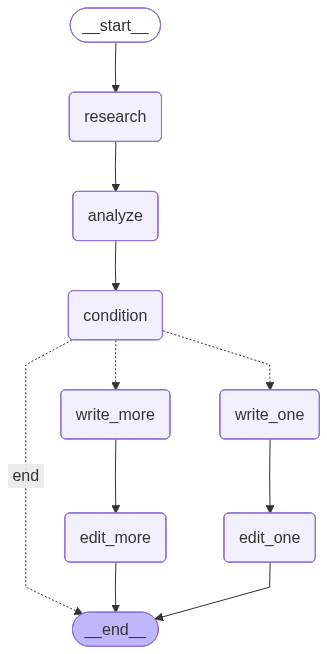

In [ ]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())